# Grid Project

## Imports

In [ ]:
import sys
sys.path.append('../../src')

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from strava_lab.storage import load_processed_activities
from strava_lab.summits import add_summit_metrics

df = load_processed_activities()
df.shape

(540, 67)

## Add Sanitas metrics to dataframe

In [20]:
df = add_summit_metrics(df, 'sanitas', 40.0344166667, -105.30525)

In [21]:
df['month'] = df['start_date_local'].dt.month
df['day'] = df['start_date_local'].dt.day

In [22]:
summits = df[df['sanitas_touches'] > 0].copy()

In [23]:
daily_counts = (
    summits
    .groupby(['month', 'day'])['sanitas_touches']
    .sum()
    .reset_index()
)


In [ ]:
calendar_df = (
    daily_counts
    .pivot(index='day', columns='month', values='sanitas_touches')
    .reindex(index=range(1, 32), columns=range(1, 13))
    .fillna(0)
    .astype(int)
)

In [ ]:
calendar_df.columns = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

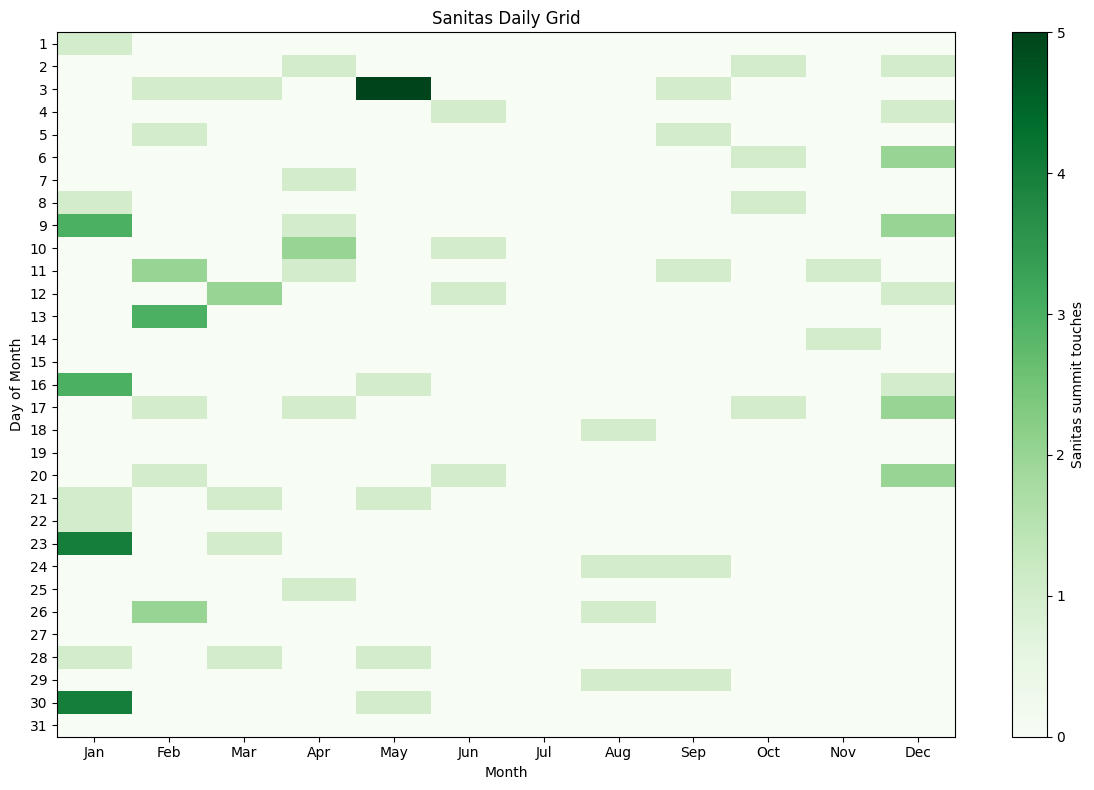

In [ ]:
plt.figure(figsize=(12, 8))

im = plt.imshow(
    calendar_df,
    aspect='auto',
    cmap='Greens',
    vmin=0  # ensures 0 is the lightest color
)

plt.colorbar(im, label='Sanitas summit touches')

plt.yticks(
    ticks=np.arange(len(calendar_df.index)),
    labels=calendar_df.index
)

plt.xticks(
    ticks=np.arange(len(calendar_df.columns)),
    labels=calendar_df.columns
)

plt.xlabel('Month')
plt.ylabel('Day of Month')
plt.title('Sanitas Daily Grid')

plt.tight_layout()
plt.show()